# MIOwAD - NN1

### Rozwiązanie: Krzysztof Osiński

Zaimplementować sieć neuronową typu MLP, w której można ustawić: liczbę warstw, liczbę neuronów w każdej z warstw i wagi poszczególnych połączeń, w tym biasów. Sieć ma używać sigmoidalnej funkcji aktywacji. Na wyjściu dopuszczana jest funkcja liniowa.

Implementacja sieci musi być przygotowana w taki sposób, żeby łatwo zmieniać:
- Architekturę, to znaczy liczbę wejść, wyjść, neuronów w warstwach ukrytych.
- Funkcję aktywacji.

Tę implementację należy następnie wykorzystać do rozwiązania zadania regresji na dostarczonych danych. Parametry sieci należy dobrać tak aby uzyskać możliwie dobrze wyniki na zbiorach danych (zbudować po jednej sieci dla każdego zbioru):
- square-simple,
- steps-large.

Rozważyć architektury sieci:
- jedna warstwa ukryta, 5 neuronów,
- jedna warstwa ukryta, 10 neuronów,
- dwie warstwy ukryte, po 5 neuronów każda.

MSE na nieznormalizowanym zbiorze testowym square-simple nie może przekraczać wartości 9. Wyliczanie MSE na zbiorze nieznormalizowanym nie oznacza, że sieć musi wewnętrznie działać na danych nieznormalizowanych. Wewnętrznie można normalizować i standaryzować dane.

Do wyznaczenia parametrów (wag) sieci na tym etapie nie używamy własnej implementacji procesu uczenia sieci, lecz należy wykorzystać gotowe biblioteki np. TensorFlow lub PyTorch. Wagi sieci nauczonej przy pomocy biblioteki należy wykorzystać (skopiować) do własnej implementacji sieci i zweryfikować poprawność jej działania (forward pass).

In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

## 1. Implementacja sieci MLP


In [3]:
class MLP_Network:
    
    def __init__(self, layer_sizes, activation_function, last_layer_linear=True):
        self.layer_sizes = layer_sizes
        self.activation_function = activation_function
        self.last_layer_linear = last_layer_linear
        self.weights = []
        self.biases = []
        self.norm_params = {}

    def set_parameters(self, weights, biases):
        self.weights = weights
        self.biases = biases

    def set_normalization(self, norm_dict):
        self.norm_params = norm_dict

    def forward(self, X):
        if self.norm_params.get('czy_znormalizowac', False):
            x_min, x_max = self.norm_params['x_min'], self.norm_params['x_max']
            a = (X - x_min) / (x_max - x_min)
        else:
            a = X
        
        num_layers = len(self.weights)
        for i in range(num_layers):
            z = np.dot(a, self.weights[i]) + self.biases[i]
            if i == num_layers - 1 and self.last_layer_linear:
                a = z
            else:
                a = self.activation_function(z)
                
        if self.norm_params.get('czy_znormalizowac', False):
            y_min, y_max = self.norm_params['y_min'], self.norm_params['y_max']
            a = a * (y_max - y_min) + y_min
            
        return a

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

## 2. Rozwiązanie zadania regresji

### 2.1. Funkcja do treningu sieci w PyTorch oraz ekstrakcji wag i biasów

In [1]:
def extract_params(model, dlugosc_treningu, dataset_id = 0, czy_znormalizowac = True, lr = 0.01):

    # Wczytanie danych
    if dataset_id == 0:
      data = csv.reader(open('../mio1/regression/square-simple-training.csv'))
      test_data = csv.reader(open('../mio1/regression/square-simple-test.csv'))
    elif dataset_id == 1:
      data = csv.reader(open('../mio1/regression/steps-large-training.csv'))
      test_data = csv.reader(open('../mio1/regression/steps-large-test.csv'))
    else:
      assert False, f"Wybrana baza danych nie jest dostępna."

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Trening zostanie wykonany na {device}")

    # Przygotowanie danych uczących
    x_list = []
    y_list = []
    for i, row in enumerate(data):
      if i > 0:
        _,x,y = row
        x = float(x)
        y = float(y)
        x_list.append(x)
        y_list.append(y)
    
    # Przygotowanie danych testowych
    test_x_list = []
    test_y_list = []
    for i, row in enumerate(test_data):
      if i > 0:
        _,x,y = row
        x = float(x)
        y = float(y)
        test_x_list.append(x)
        test_y_list.append(y)

    
    # Stałe do normalizacji
    x_train_tensor = torch.tensor(x_list).reshape(-1,1).to(device)
    y_train_tensor = torch.tensor(y_list).reshape(-1,1).to(device)
    x_min, x_max = x_train_tensor.min(), x_train_tensor.max()
    y_min, y_max = y_train_tensor.min(), y_train_tensor.max()

    # Funkcja straty
    criterion = nn.MSELoss()
    # Optymalizator
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Trening
    for i in range(dlugosc_treningu):
      x_to_plot = []
      y_to_plot = []
      y_pred_to_plot = []
    
      x = torch.tensor(x_list).reshape(-1,1).to(device)
      y = torch.tensor(y_list).reshape(-1,1).to(device)
    
      if czy_znormalizowac:
        x_normalized = (x - x_min) / (x_max - x_min)
        y_normalized = (y - y_min) / (y_max - y_min)
      else:
        x_normalized = x
        y_normalized = y
    
      y_pred = model(x_normalized)
    
      x_to_plot = x_to_plot + x.tolist()
      y_to_plot = y_to_plot + y.tolist()
      y_pred_to_plot = y_pred_to_plot + (y_pred*(y.max() - y.min()) + y.min()).tolist()
    
      loss = criterion(y_pred, y_normalized)
    
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      if i % 1000 == 0:
        print(f"Wartość funkcja straty podczas treningu, krok: {i}, {loss.item()}")

    print("TRAIN")
    if czy_znormalizowac:
      print(f"Znormalizowana finalna wartość funkcji straty: {loss.item()}")
      normalized_loss = criterion( y_pred*(y_max - y_min) + y_min , y)
      print(f"Nieznormalizowana finalna wartość funkcji straty: {normalized_loss.item()}")
    else:
      print(f"Nieznormalizowana finalna wartość funkcji straty: {loss.item()}")

    # Wyświetl jak wygląda predykcja modelu dla ostatniego kroku
    print('\nWYKRES TRENINGOWY (Ostatni krok):')
    plt.scatter(x_to_plot, y_to_plot)
    plt.scatter(x_to_plot, y_pred_to_plot)
    plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
    plt.title('Trening - ostatni krok')
    plt.show()
 
    # Przetestuj model na zbiorze testowym
    test_x_to_plot = []
    test_y_to_plot = []
    test_y_pred_to_plot = []
    
    x = torch.tensor(test_x_list).reshape(-1,1).to(device)
    y = torch.tensor(test_y_list).reshape(-1,1).to(device)
    
    if czy_znormalizowac:
      x_normalized = (x - x_min) / (x_max - x_min)
      y_normalized = (y - y_min) / (y_max - y_min)
    else:
      x_normalized = x
      y_normalized = y
    
    y_pred = model(x_normalized)
    
    test_x_to_plot = test_x_to_plot + x.tolist()
    test_y_to_plot = test_y_to_plot + y.tolist()
    test_y_pred_to_plot = test_y_pred_to_plot + (y_pred*(y_max - y_min) + y_min).tolist()
    
    loss = criterion(y_pred, y_normalized)

    print("TEST")
    if czy_znormalizowac:
      print(f"Znormalizowana finalna wartość funkcji straty: {loss.item()}")
      normalized_loss = criterion( y_pred*(y_max - y_min) + y_min , y)
      print(f"Nieznormalizowana finalna wartość funkcji straty: {normalized_loss.item()}")
    else:
      print(f"Nieznormalizowana finalna wartość funkcji straty: {loss.item()}")

    # Wyświetl prawdziwą wartość funkcji i przewidzianą wartość nieznormalizowaną
    print('WYKRES TESTOWY:')
    plt.scatter(test_x_to_plot, test_y_to_plot)
    plt.scatter(test_x_to_plot, test_y_pred_to_plot)
    plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
    plt.title('Wynik na zbiorze testowym')
    plt.show()

    
    # Ekstrakcja parametrów
    weights = []
    biases = []
    
    for layer in model:
        if isinstance(layer, nn.Linear):
            # PyTorch: y = x*W^T + b | NumPy: y = x*W + b
            weights.append(layer.weight.data.cpu().numpy().T)
            biases.append(layer.bias.data.cpu().numpy())

    # Stałe normalizacji
    norm_constants = {
        'x_min': x_min.item(), 'x_max': x_max.item(),
        'y_min': y_min.item(), 'y_max': y_max.item(),
        'czy_znormalizowac': czy_znormalizowac
    }

    X_test_raw = np.array(test_x_list).reshape(-1, 1)
    y_test_raw = np.array(test_y_list).reshape(-1, 1)
    
    return weights, biases, norm_constants, X_test_raw, y_test_raw

### 2.2. Funkcja do porównania wyników

Porównujemy wyniki sieci z PyTorch do własnej implementacji z podstawionymi wagami.

In [11]:
def compare_mlp_implementations(model, layer_sizes, dlugosc_treningu = 5000, dataset_id = 0, lr = 0.01):
    
    w, b, norm, X_test, y_test = extract_params(model, dlugosc_treningu, dataset_id, lr=lr)

    print("WŁASNA IMPLEMENTACJA")                       
    mlp = MLP_Network(
        layer_sizes = layer_sizes, 
        activation_function = sigmoid,
        last_layer_linear = True
    )
    
    # Wstrzyknięcie wag z PyTorcha
    mlp.set_parameters(w, b)
    mlp.set_normalization(norm)
    
    # Predykcja
    y_pred_final = mlp.forward(X_test)
    
    # MSE
    mse = np.mean((y_test - y_pred_final)**2)
    print(f"Finalne MSE mojej implementacji: {mse:.4f}")
    
    X_test_scaled = (X_test - norm['x_min']) / (norm['x_max'] - norm['x_min'])
    
    with torch.no_grad():
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        model.eval()
        torch_output_norm = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()
        y_pred_norm_custom = (y_pred_final - norm['y_min']) / (norm['y_max'] - norm['y_min'])
        roznica = np.abs(y_pred_norm_custom - torch_output_norm).max()
        print(f"Maksymalna różnica między NumPy a PyTorch: {roznica:.8f}")
    
    # Wykres
    plt.figure(figsize=(10, 6))
    plt.scatter(X_test, y_test, color='blue', label='Dane testowe (Prawdziwe)', alpha=0.5)
    plt.scatter(X_test, y_pred_final, color='red', marker='x', label='Moja sieć (NumPy)')
    plt.title(f"Finalne dopasowanie mojej sieci (MSE: {mse:.4f})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

### 2.3. Definicja modeli i porównanie

In [19]:
model_1 = nn.Sequential(
    nn.Linear(1, 5),
    nn.Sigmoid(),
    nn.Linear(5, 1)
)
layer_sizes_1 = [1, 5, 1]

model_2 = nn.Sequential(
    nn.Linear(1, 10),
    nn.Sigmoid(),
    nn.Linear(10, 1)
)
layer_sizes_2 = [1, 10, 1]

model_3 = nn.Sequential(
    nn.Linear(1, 5),
    nn.Sigmoid(),
    nn.Linear(5, 5),
    nn.Sigmoid(), 
    nn.Linear(5, 1)
)
layer_sizes_3 = [1, 5, 5, 1]

#### 2.3.1. Zbiór danych square-simple

Trening zostanie wykonany na cpu
Wartość funkcja straty podczas treningu, krok: 0, 0.16551370918750763
Wartość funkcja straty podczas treningu, krok: 1000, 0.0010986526031047106
Wartość funkcja straty podczas treningu, krok: 2000, 0.00016595717170275748
Wartość funkcja straty podczas treningu, krok: 3000, 3.214884054614231e-05
Wartość funkcja straty podczas treningu, krok: 4000, 1.8569082385511138e-05
TRAIN
Znormalizowana finalna wartość funkcji straty: 1.2865124517702498e-05
Nieznormalizowana finalna wartość funkcji straty: 1.4755423069000244

WYKRES TRENINGOWY (Ostatni krok):


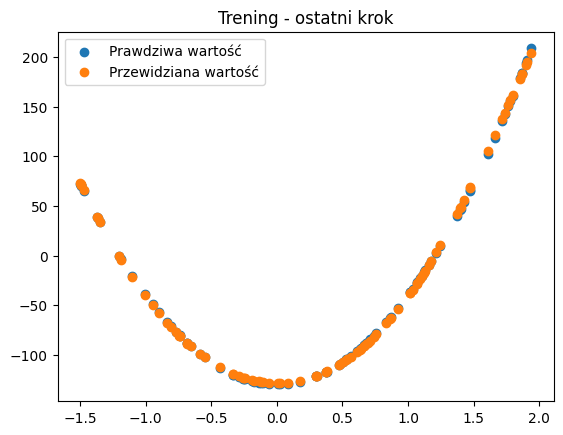

TEST
Znormalizowana finalna wartość funkcji straty: 1.4724963875778485e-05
Nieznormalizowana finalna wartość funkcji straty: 1.6888525485992432
WYKRES TESTOWY:


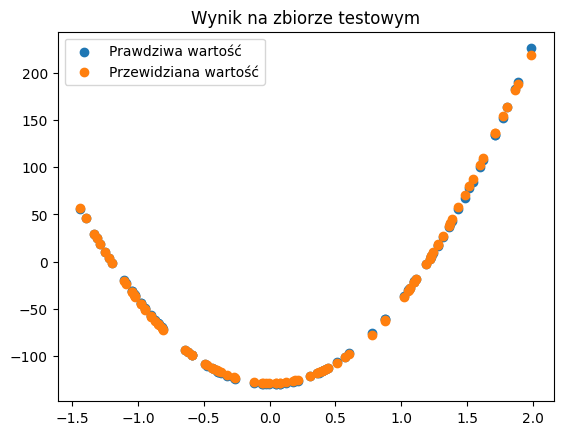

WŁASNA IMPLEMENTACJA
Finalne MSE mojej implementacji: 1.6888
Maksymalna różnica między NumPy a PyTorch: 0.00000013


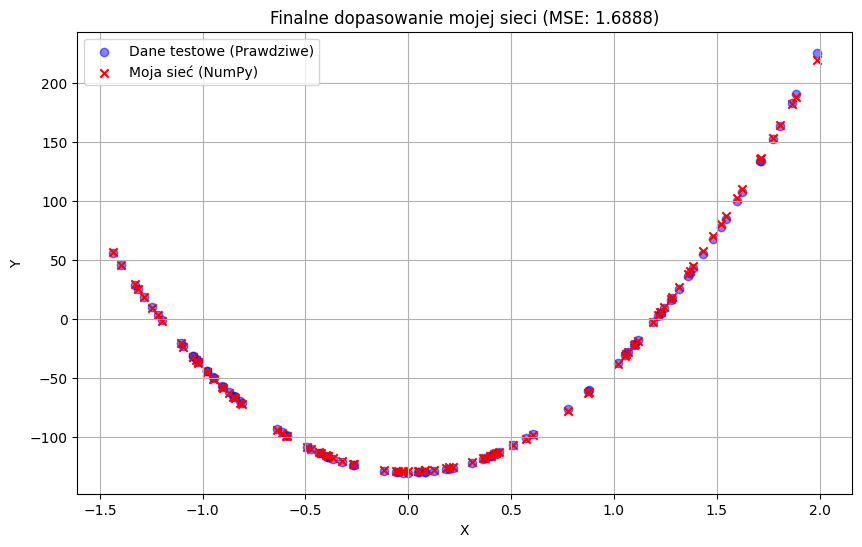

In [10]:
compare_mlp_implementations(model_1, layer_sizes_1, dlugosc_treningu = 5000, dataset_id = 0)

Trening zostanie wykonany na cpu
Wartość funkcja straty podczas treningu, krok: 0, 0.09419867396354675
Wartość funkcja straty podczas treningu, krok: 1000, 4.359956437838264e-05
Wartość funkcja straty podczas treningu, krok: 2000, 4.174034529569326e-06
Wartość funkcja straty podczas treningu, krok: 3000, 2.158616325687035e-06
Wartość funkcja straty podczas treningu, krok: 4000, 1.7211334579769755e-06
TRAIN
Znormalizowana finalna wartość funkcji straty: 1.4771262613066938e-06
Nieznormalizowana finalna wartość funkcji straty: 0.16941651701927185

WYKRES TRENINGOWY (Ostatni krok):


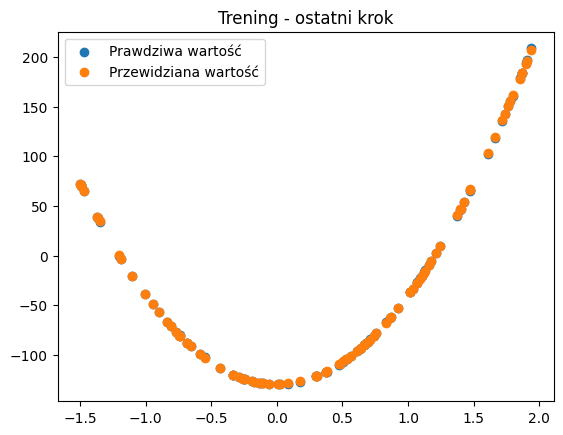

TEST
Znormalizowana finalna wartość funkcji straty: 1.8938482071462204e-06
Nieznormalizowana finalna wartość funkcji straty: 0.2172124683856964
WYKRES TESTOWY:


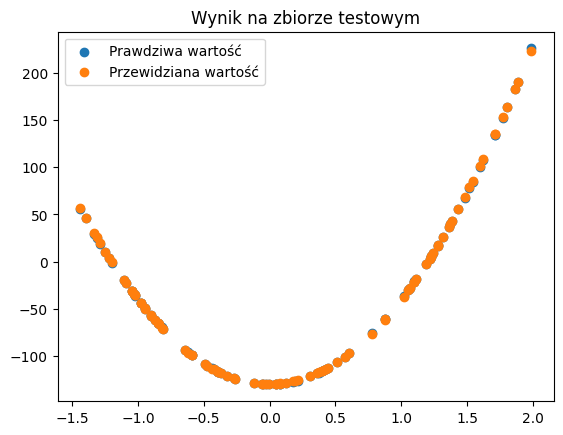

WŁASNA IMPLEMENTACJA
Finalne MSE mojej implementacji: 0.2172
Maksymalna różnica między NumPy a PyTorch: 0.00000025


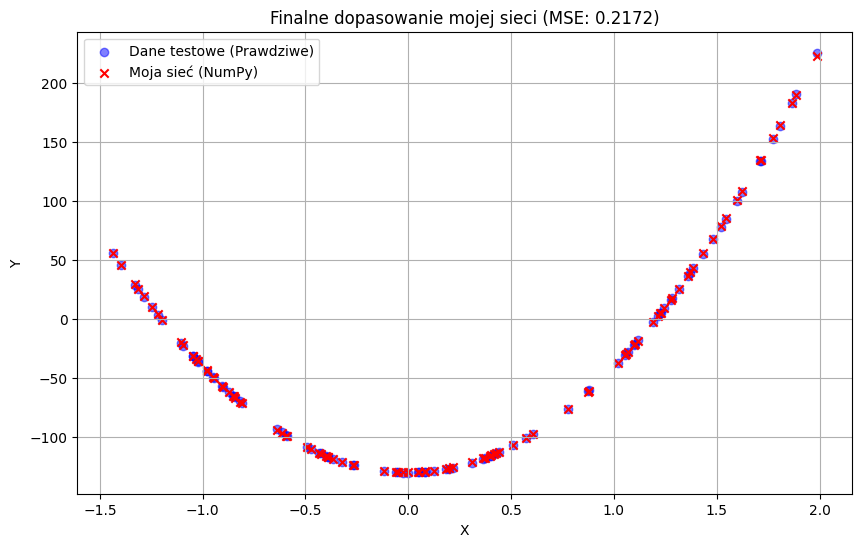

In [13]:
compare_mlp_implementations(model_2, layer_sizes_2, dlugosc_treningu = 5000, dataset_id = 0)

Trening zostanie wykonany na cpu
Wartość funkcja straty podczas treningu, krok: 0, 0.08497320860624313
Wartość funkcja straty podczas treningu, krok: 1000, 4.6138608013279736e-05
Wartość funkcja straty podczas treningu, krok: 2000, 2.7122830942971632e-05
Wartość funkcja straty podczas treningu, krok: 3000, 1.3424562894215342e-05
Wartość funkcja straty podczas treningu, krok: 4000, 8.61010357766645e-06
TRAIN
Znormalizowana finalna wartość funkcji straty: 5.199889983487083e-06
Nieznormalizowana finalna wartość funkcji straty: 0.5963921546936035

WYKRES TRENINGOWY (Ostatni krok):


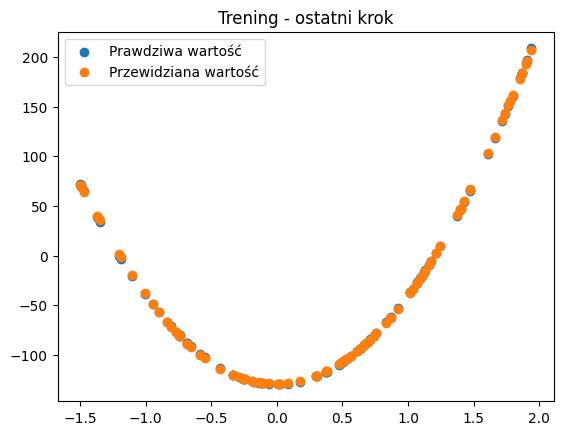

TEST
Znormalizowana finalna wartość funkcji straty: 6.656876848865068e-06
Nieznormalizowana finalna wartość funkcji straty: 0.7634984850883484
WYKRES TESTOWY:


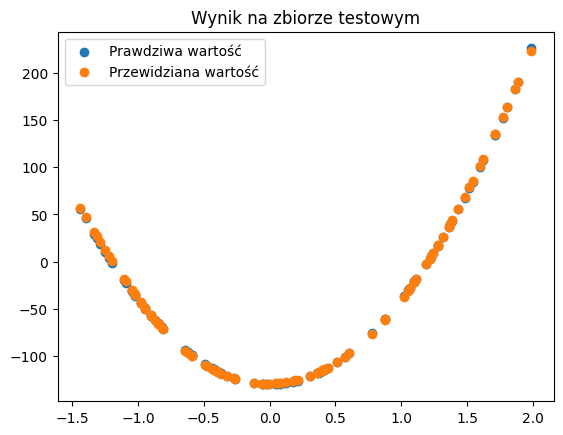

WŁASNA IMPLEMENTACJA
Finalne MSE mojej implementacji: 0.7635
Maksymalna różnica między NumPy a PyTorch: 0.00000028


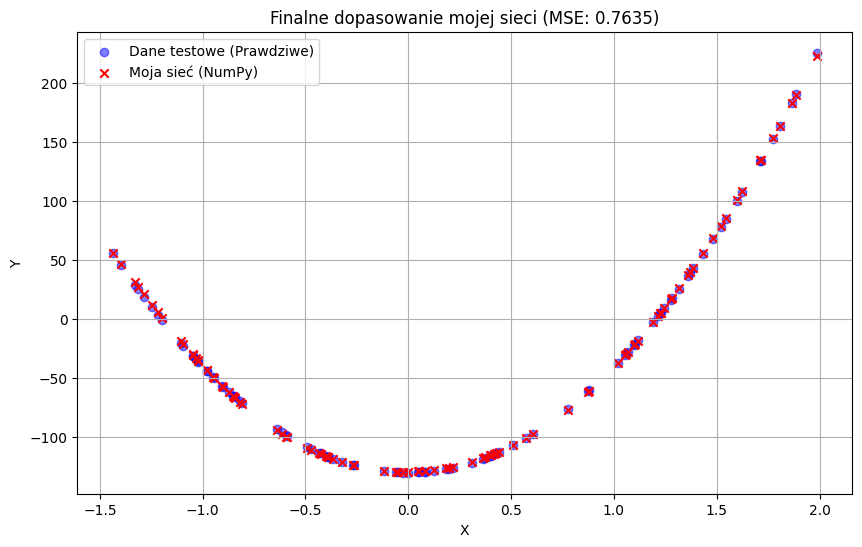

In [14]:
compare_mlp_implementations(model_1, layer_sizes_1, dlugosc_treningu = 5000, dataset_id = 0)

#### 2.3.1. Zbiór danych steps-large

W tym notebooku przypadkiem nadpisałem wytrenowane modele sieci z 1 warstwą ukrytą (z 5 neuronami oraz z 10 neuronami) i straciłem postęp (m.in. wykresy). Wcześniej udało się wytrenować sieć w PyTorch do takiego poziomu (przy 80k steps i lr=0.01):

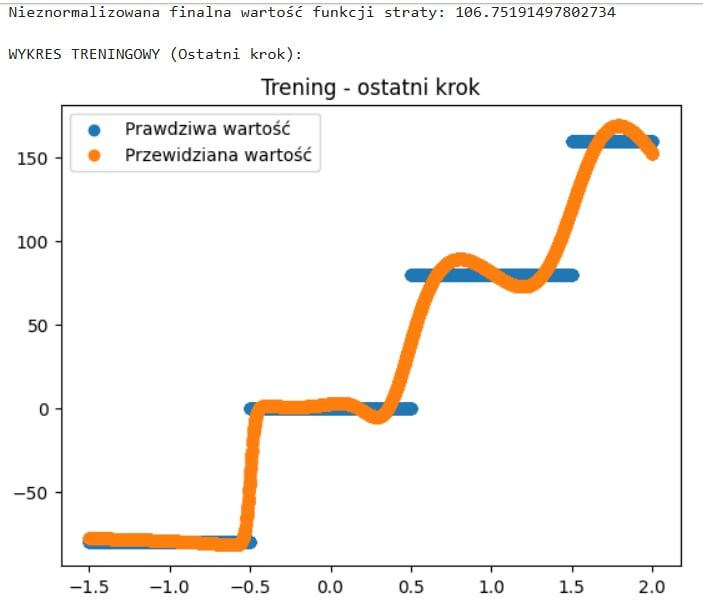

Natomiast w Google Colab udało się jeszcze raz wytrenować sieć do takiego poziomu:

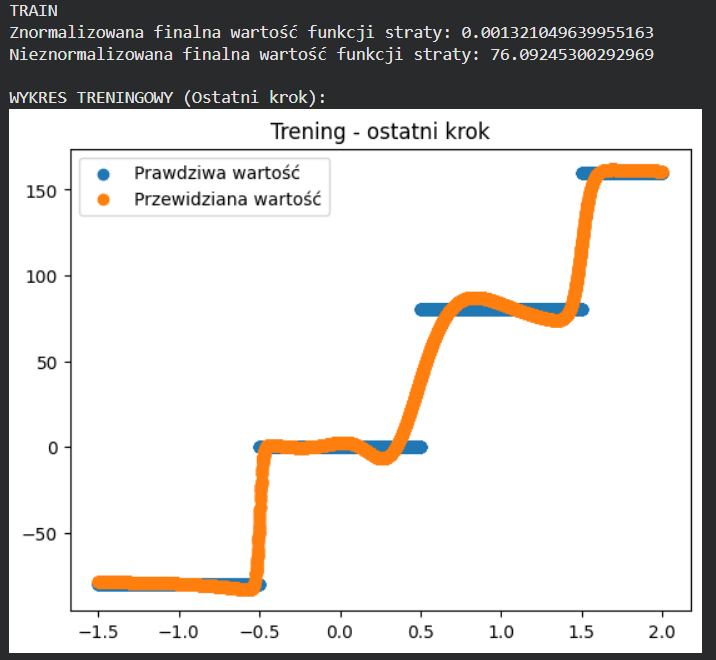

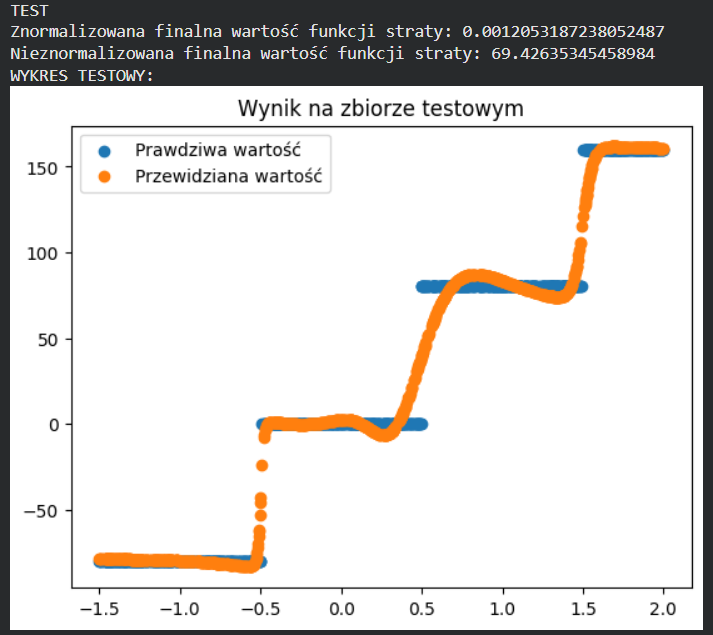

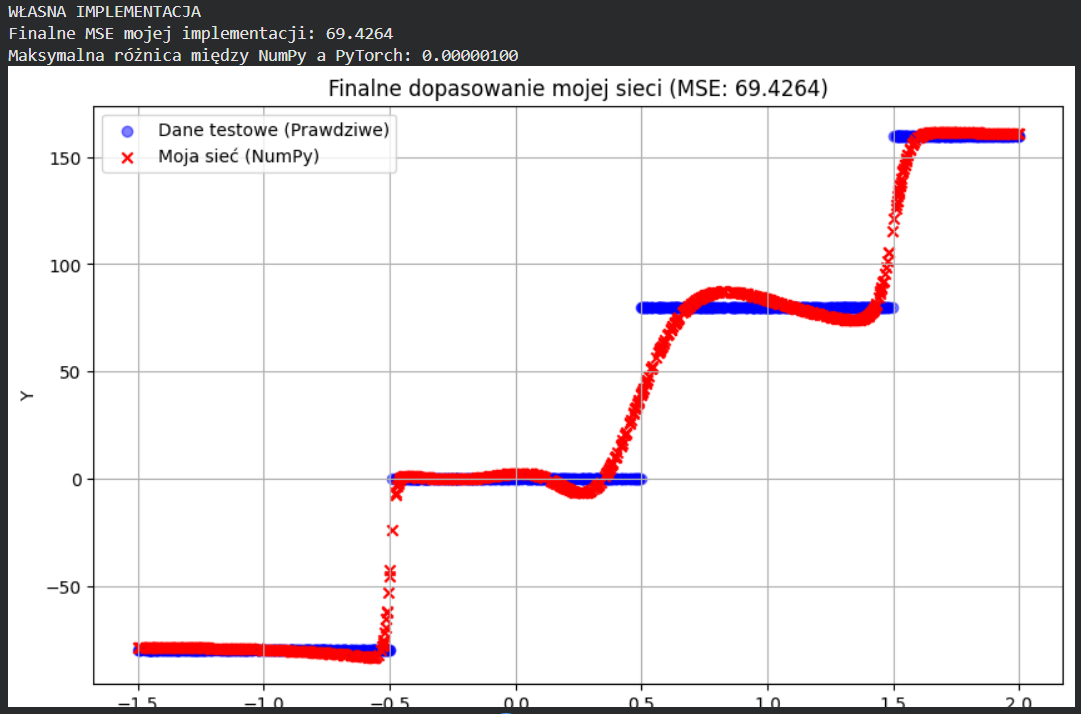

### Poniżej wyniki dla 3 architektur przy lr = 0.005 i 50k steps

Trening zostanie wykonany na cpu
Wartość funkcja straty podczas treningu, krok: 0, 0.008342941291630268
Wartość funkcja straty podczas treningu, krok: 1000, 0.008304867893457413
Wartość funkcja straty podczas treningu, krok: 2000, 0.007957425899803638
Wartość funkcja straty podczas treningu, krok: 3000, 0.007615727372467518
Wartość funkcja straty podczas treningu, krok: 4000, 0.007244694512337446
Wartość funkcja straty podczas treningu, krok: 5000, 0.007214264012873173
Wartość funkcja straty podczas treningu, krok: 6000, 0.007188255432993174
Wartość funkcja straty podczas treningu, krok: 7000, 0.007125393021851778
Wartość funkcja straty podczas treningu, krok: 8000, 0.007001807447522879
Wartość funkcja straty podczas treningu, krok: 9000, 0.006846270523965359
Wartość funkcja straty podczas treningu, krok: 10000, 0.006695781834423542
Wartość funkcja straty podczas treningu, krok: 11000, 0.006570315454155207
Wartość funkcja straty podczas treningu, krok: 12000, 0.006479566916823387
Warto

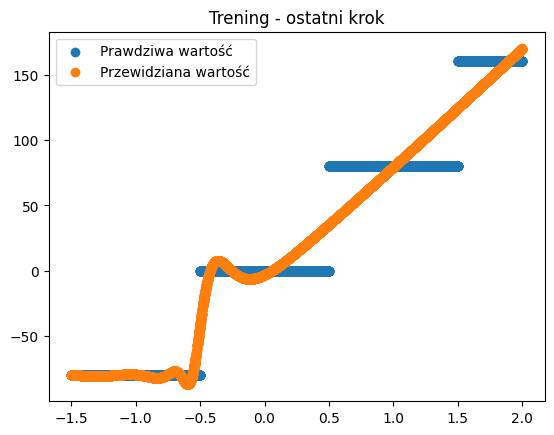

TEST
Znormalizowana finalna wartość funkcji straty: 0.005373673513531685
Nieznormalizowana finalna wartość funkcji straty: 309.5235900878906
WYKRES TESTOWY:


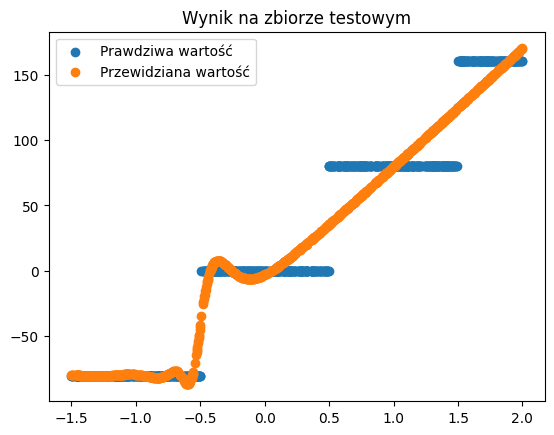

WŁASNA IMPLEMENTACJA
Finalne MSE mojej implementacji: 309.5236
Maksymalna różnica między NumPy a PyTorch: 0.00000076


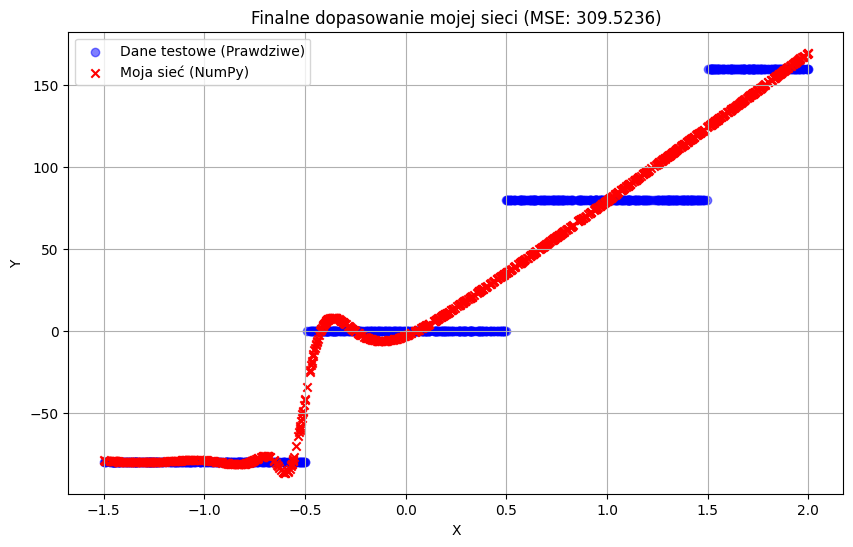

In [21]:
compare_mlp_implementations(model_1, layer_sizes_1, dlugosc_treningu = 50000, dataset_id = 1, lr = 0.005)

Trening zostanie wykonany na cpu
Wartość funkcja straty podczas treningu, krok: 0, 0.28123074769973755
Wartość funkcja straty podczas treningu, krok: 1000, 0.008797076530754566
Wartość funkcja straty podczas treningu, krok: 2000, 0.00837907288223505
Wartość funkcja straty podczas treningu, krok: 3000, 0.00831859651952982
Wartość funkcja straty podczas treningu, krok: 4000, 0.008312741294503212
Wartość funkcja straty podczas treningu, krok: 5000, 0.008306965231895447
Wartość funkcja straty podczas treningu, krok: 6000, 0.00830124318599701
Wartość funkcja straty podczas treningu, krok: 7000, 0.008295993320643902
Wartość funkcja straty podczas treningu, krok: 8000, 0.008291446603834629
Wartość funkcja straty podczas treningu, krok: 9000, 0.008283600211143494
Wartość funkcja straty podczas treningu, krok: 10000, 0.008269591256976128
Wartość funkcja straty podczas treningu, krok: 11000, 0.008235673420131207
Wartość funkcja straty podczas treningu, krok: 12000, 0.008017348125576973
Wartość f

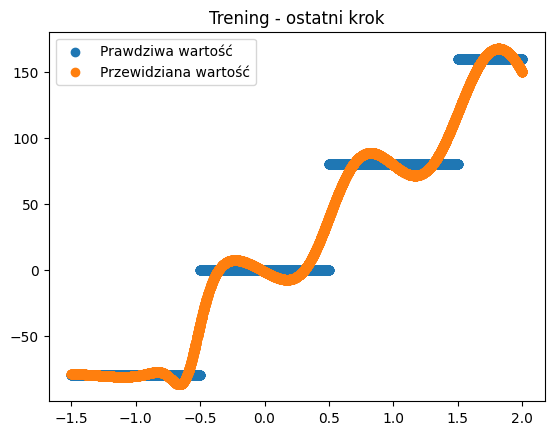

TEST
Znormalizowana finalna wartość funkcji straty: 0.0025105022359639406
Nieznormalizowana finalna wartość funkcji straty: 144.6049346923828
WYKRES TESTOWY:


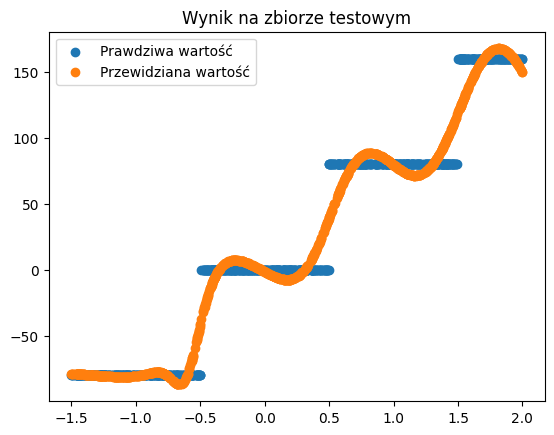

WŁASNA IMPLEMENTACJA
Finalne MSE mojej implementacji: 144.6048
Maksymalna różnica między NumPy a PyTorch: 0.00000078


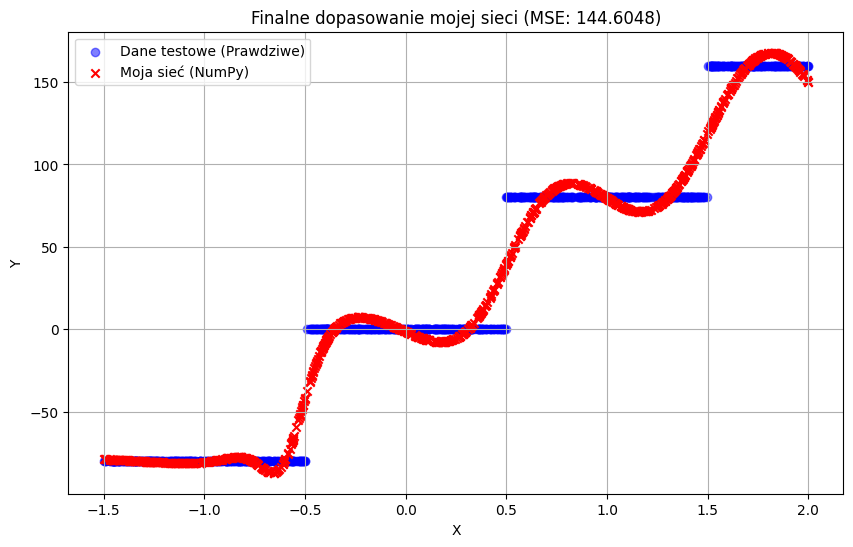

In [22]:
compare_mlp_implementations(model_2, layer_sizes_2, dlugosc_treningu = 50000, dataset_id = 1, lr = 0.005)

Trening zostanie wykonany na cpu
Wartość funkcja straty podczas treningu, krok: 0, 0.0006161234923638403
Wartość funkcja straty podczas treningu, krok: 1000, 0.0006100988248363137
Wartość funkcja straty podczas treningu, krok: 2000, 0.0005996038089506328
Wartość funkcja straty podczas treningu, krok: 3000, 0.0005882066325284541
Wartość funkcja straty podczas treningu, krok: 4000, 0.0005776800098828971
Wartość funkcja straty podczas treningu, krok: 5000, 0.0005676037981174886
Wartość funkcja straty podczas treningu, krok: 6000, 0.0005580339930020273
Wartość funkcja straty podczas treningu, krok: 7000, 0.0005488761235028505
Wartość funkcja straty podczas treningu, krok: 8000, 0.0005401039379648864
Wartość funkcja straty podczas treningu, krok: 9000, 0.0005316967726685107
Wartość funkcja straty podczas treningu, krok: 10000, 0.000524116971064359
Wartość funkcja straty podczas treningu, krok: 11000, 0.0005158020067028701
Wartość funkcja straty podczas treningu, krok: 12000, 0.0005083240102

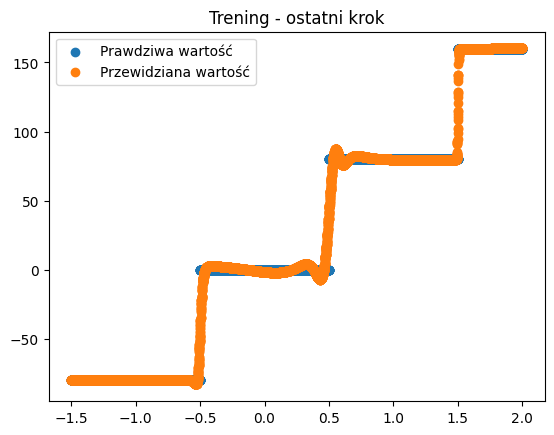

TEST
Znormalizowana finalna wartość funkcji straty: 0.0003066464269068092
Nieznormalizowana finalna wartość funkcji straty: 17.662837982177734
WYKRES TESTOWY:


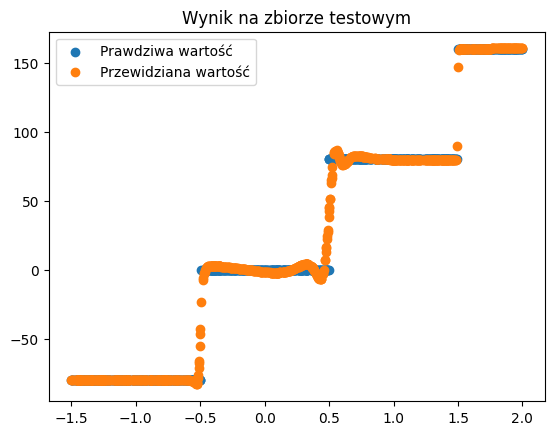

WŁASNA IMPLEMENTACJA
Finalne MSE mojej implementacji: 17.6628
Maksymalna różnica między NumPy a PyTorch: 0.00000172


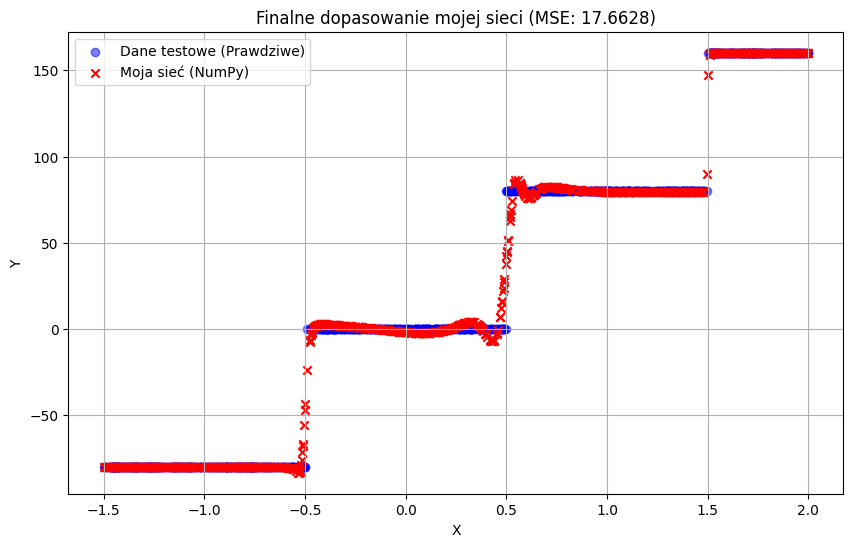

In [18]:
compare_mlp_implementations(model_3, layer_sizes_3, dlugosc_treningu = 50000, dataset_id = 1, lr = 0.005)

In [ ]:
# # Kod do zapisu stanu modelu i optimizera
# checkpoint = {
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'epoch': i,
#     'loss': loss.item()
# }
# torch.save(checkpoint, 'checkpoint_steps_large.pth')

# # Wczytanie
# model = nn.Sequential(nn.Linear(1, 5), nn.Sigmoid(), nn.Linear(5, 5), nn.Sigmoid(), nn.Linear(5, 1))
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# checkpoint = torch.load('checkpoint_steps_large.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
